In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-05-29 17:37:22.098449: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 17:37:22.155572: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-29 17:37:23.087586: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
# train/validation/test = 70/10/20
dataset = pd.read_csv('dataset/ngtdm/kernel5-radius5/dataset.200p.csv')

train_data, temp_data = train_test_split(
    dataset, test_size=0.3, random_state=42
 )
validation_data, test_data = train_test_split(
    temp_data, test_size=2/3, random_state=42
 )

In [4]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-05-29 17:37:25.662644: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-29 17:37:25.663104: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
import keras

In [6]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp35gp2ndl as temporary training directory
Reading training dataset...
Training dataset read in 0:00:02.842560. Found 157360 examples.
Training model...


[INFO 26-05-29 17:37:41.8915 UTC kernel.cc:1233] Loading model from path /tmp/tmp35gp2ndl/model/ with prefix fb3921391d6340fe
[INFO 26-05-29 17:37:43.2469 UTC decision_forest.cc:734] Model loaded with 300 root(s), 1124756 node(s), and 5 input feature(s).
[INFO 26-05-29 17:37:43.2469 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-05-29 17:37:43.2469 UTC kernel.cc:1061] Use fast generic engine


Model trained in 0:00:14.784270
Compiling model...
Model compiled.
CPU times: user 2min 46s, sys: 1.57 s, total: 2min 47s
Wall time: 20.5 s


In [7]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

23/23 [==============================] - 3s 33ms/step - loss: 0.0000e+00 - accuracy: 0.9056

loss: 0.0000
accuracy: 0.9056


In [8]:
# Model Summary
model.summary()

Model: "random_forest_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
Total params: 1 (1.00 Byte)
Trainable params: 0 (0.00 Byte)
Non-trainable params: 1 (1.00 Byte)
_________________________________________________________________
Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (5):
	Busyness
	Coarseness
	Complexity
	Contrast
	Strength

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1. "Coarseness"  0.777283 ################
    2.   "Busyness"  0.437192 #######
    3. "Complexity"  0.148387 
    4.   "Contrast"  0.122101 
    5.   "Strength"  0.113185 

Variable Importance: NUM_AS_ROOT:
    1. "Coarseness" 238.000000 ################
    2.   "Busyness" 62.000000 

Variable Importance: NUM_NODES:
    1.   "Busyness" 128398.000000 ################
    2.   "Strength" 113825.000000 ########
    3.   "Contrast" 111788.000000 ######
    4. "Complexity

In [9]:
# Model features
model.make_inspector().features()

["Busyness" (1; #0),
 "Coarseness" (1; #1),
 "Complexity" (1; #2),
 "Contrast" (1; #3),
 "Strength" (1; #4)]

In [10]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Coarseness" (1; #1), 0.7772832264312532),
  ("Busyness" (1; #0), 0.43719207233371443),
  ("Complexity" (1; #2), 0.14838747918097184),
  ("Contrast" (1; #3), 0.12210112978372895),
  ("Strength" (1; #4), 0.11318549526239821)],
 'NUM_AS_ROOT': [("Coarseness" (1; #1), 238.0), ("Busyness" (1; #0), 62.0)],
 'SUM_SCORE': [("Coarseness" (1; #1), 9649062.157939505),
  ("Busyness" (1; #0), 7349312.9877722105),
  ("Complexity" (1; #2), 3341816.9011264592),
  ("Contrast" (1; #3), 2485113.1750661256),
  ("Strength" (1; #4), 2484914.4402431496)],
 'NUM_NODES': [("Busyness" (1; #0), 128398.0),
  ("Strength" (1; #4), 113825.0),
  ("Contrast" (1; #3), 111788.0),
  ("Complexity" (1; #2), 109324.0),
  ("Coarseness" (1; #1), 98893.0)]}

In [11]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=157360, accuracy=0.835470456972245, loss=0.5897471040385879, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

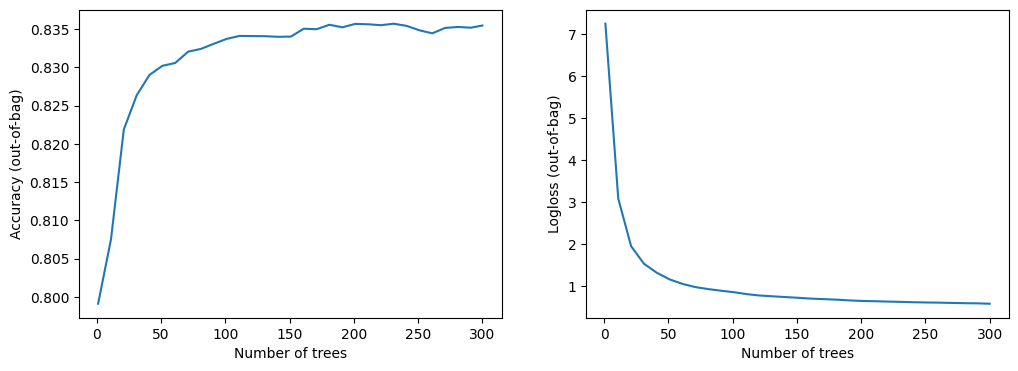

In [12]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [13]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

23/23 [==============================] - 1s 32ms/step
The ROC AUC score is 0.92707


In [14]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

45/45 [==============================] - 4s 95ms/step
Sklearn binary metrics:
accuracy: 0.9086
precision: 0.3917
recall: 0.7573
f1: 0.5164
mcc: 0.5029
roc_auc: 0.9305
pr_auc: 0.5798
log_loss: 0.2231
brier_score: 0.0663

Confusion matrix:
 [[38660  3405]
 [  703  2193]]

Classification report:
               precision    recall  f1-score   support

           0     0.9821    0.9191    0.9496     42065
           1     0.3917    0.7573    0.5164      2896

    accuracy                         0.9086     44961
   macro avg     0.6869    0.8382    0.7330     44961
weighted avg     0.9441    0.9086    0.9216     44961

